In [ ]:
# ADAM OPTIMIZER

import numpy as np
import matplotlib.pyplot as plt

In [ ]:


# --------------------------------------------
# 1. Dataset
# --------------------------------------------

np.random.seed(42)

X = np.linspace(-5, 5, 100)
y = 3 * X + 2 + np.random.randn(100) * 0.5

# --------------------------------------------
# 2. Parameters
# --------------------------------------------

w = 0.0
b = 0.0

learning_rate = 0.01

beta1 = 0.9
beta2 = 0.999
epsilon = 1e-8

epochs = 100

# First moment
m_w = 0.0
m_b = 0.0

# Second moment
v_w = 0.0
v_b = 0.0

loss_history = []

# --------------------------------------------
# 3. Adam Training
# --------------------------------------------

for t in range(1, epochs + 1):

    # Prediction
    y_pred = w * X + b

    # Error
    error = y_pred - y

    # Loss
    loss = np.mean(error ** 2)
    loss_history.append(loss)

    # Gradients
    dw = np.mean(2 * X * error)
    db = np.mean(2 * error)

    # First moment
    m_w = beta1 * m_w + (1 - beta1) * dw
    m_b = beta1 * m_b + (1 - beta1) * db

    # Second moment
    v_w = beta2 * v_w + (1 - beta2) * (dw ** 2)
    v_b = beta2 * v_b + (1 - beta2) * (db ** 2)

    # Bias correction
    m_w_corrected = m_w / (1 - beta1 ** t)
    m_b_corrected = m_b / (1 - beta1 ** t)

    v_w_corrected = v_w / (1 - beta2 ** t)
    v_b_corrected = v_b / (1 - beta2 ** t)

    # Parameter update
    w = w - learning_rate * m_w_corrected / (
        np.sqrt(v_w_corrected) + epsilon
    )

    b = b - learning_rate * m_b_corrected / (
        np.sqrt(v_b_corrected) + epsilon
    )


# --------------------------------------------
# 4. Results
# --------------------------------------------

print("Adam Results")
print("Weight:", w)
print("Bias:", b)
print("Final Loss:", loss_history[-1])


# --------------------------------------------


Adam Results
Weight: 0.9377112877982204
Bias: 0.8985335098634216
Final Loss: 38.02104859937986


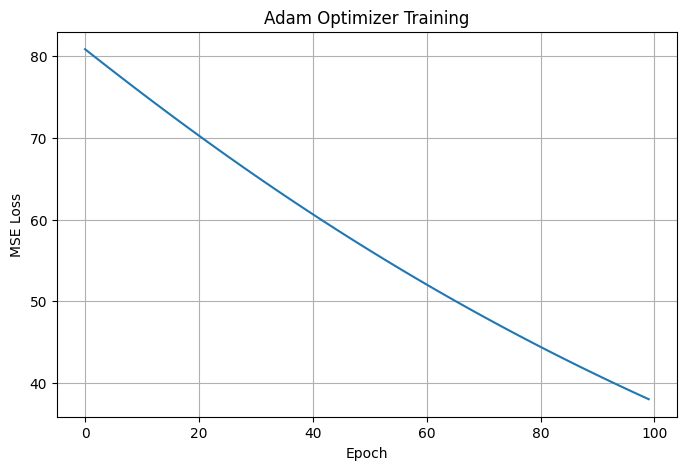

In [ ]:
# 5. Plot
# --------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(loss_history)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Adam Optimizer Training")
plt.grid()

plt.show()